# 🌦️ WeatherOps Statistical Models — Ground-Truth Corrected
## Three rounds of debugging → the real causes of AUC=1.0

### Full forensic trail

| Round | What we diagnosed | Why it still failed |
|-------|-------------------|---------------------|
| **v1** | `heat_hazard_score`, `landslide_susceptibility`, `wind_elevation_product` in features | Applied "IMD rules" using `rainfall_24h ≥ 64.5` — but max value in this dataset is **5.3 mm** → condition always False → all-zero label |
| **v2** | All-zero label → AUC=1.0 on trivial all-zero test set | Discovered `flood_occurred = river_distance < ~500m`; `river_distance` was still in features |
| **v3 (this notebook)** | Inspected the **actual 22-column CSV** | Designed labels that provably can't be predicted from their own definition columns |

### Dataset reality (22 columns, 2000 rows, ~1784 in ROI)
```
Available columns: elevation, slope, aspect, twi, rainfall_24h, rainfall_3h,
                   river_distance, drainage_distance, flow_accumulation,
                   soil_moisture, urban_density, LST_C_mean, wind_kmh,
                   temp_C, road_distance, facility_distance, lat, lon,
                   flood_occurred (binary), in_roi
```

### Why perfect scores keep appearing in DEM-derived datasets
All terrain variables (slope, TWI, elevation, flow_accumulation) are computed from
the same DEM. They are mutually highly correlated (slope ↔ TWI r = −0.88).  
Any label built from one terrain variable is **near-perfectly predictable by the others**.  
This is not a modeling failure — it is a structural property of synthetic DEM grids.

### What we do about it

| Hazard | Label | Excluded from features | Max single-feature AUC |
|--------|-------|------------------------|------------------------|
| 🌊 Flood | Original `flood_occurred` (river proximity rule) | `river_distance`, `drainage_distance` | **0.75** (elevation) |
| 🔥 Heat | `LST_C_mean ≥ Q75` (thermal hotspot) | `LST_C_mean` | **0.52** (aspect) — genuinely hard |
| 💨 Wind | `wind_kmh` regression | — | max corr −0.14 (lon) |
| ⛰️ Landslide | `rainfall_3h ≥ Q90` + `slope ≥ Q50` trigger | `rainfall_3h`, `slope` | **0.83** (lon) — safe |

### Realistic expected ranges (literature)
| Hazard | Expected | This dataset |
|--------|----------|-------------|
| Flood  | AUC 0.72–0.82 | ~0.75–0.85 |
| Heat   | AUC 0.65–0.80 | ~0.50–0.60 (LST unrelated to available features) |
| Wind   | R² 0.35–0.65 | ~0.30–0.55 (terrain weakly correlated with IDW wind) |
| Landslide | AUC 0.60–0.78 | ~0.60–0.75 |


---
## Section 0 — Imports & Setup

In [1]:
%pip install scikit-learn xgboost imbalanced-learn shap matplotlib seaborn openpyxl --quiet


Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    average_precision_score, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, brier_score_loss,
    mean_squared_error, mean_absolute_error, r2_score, accuracy_score,
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier, XGBRegressor

try:
    import shap; HAS_SHAP = True
except ImportError:
    HAS_SHAP = False; print("pip install shap for SHAP plots")

# ── Dark theme
plt.rcParams.update({
    "figure.facecolor":"#111318","axes.facecolor":"#111318","axes.edgecolor":"#2a2f3d",
    "axes.labelcolor":"#8a93a8","xtick.color":"#8a93a8","ytick.color":"#8a93a8",
    "text.color":"#e8ecf4","grid.color":"#2a2f3d","grid.linewidth":.5,
    "axes.grid":True,"font.family":"monospace","figure.dpi":120,
})
A="#f0a500"; T="#00c9a7"; R="#e84040"; O="#f06830"; P="#a78bfa"
PAL=[A,T,R,O,P]

DATA_XLSX = Path(r"C:/Users/shoai/Downloads/WeatherOps/notebooks/data/output/weatherops_feature_table.xlsx")
OUT       = Path(r"C:/Users/shoai/Downloads/WeatherOps/notebooks/data/output/models_v3")
OUT.mkdir(exist_ok=True)
print("Output directory:", OUT)


Output directory: C:\Users\shoai\Downloads\WeatherOps\notebooks\data\output\models_v3


---
## Section 1 — Load & Full Data Audit

In [3]:
df_raw = pd.read_excel(DATA_XLSX)
df = df_raw[df_raw["in_roi"] == 1].reset_index(drop=True)
print(f"Full dataset: {df_raw.shape}  →  ROI subset: {df.shape}")

print("\nAll columns:")
for c in df.columns:
    s = df[c]
    if pd.api.types.is_numeric_dtype(s):
        print(f"  {c:35s}  nuniq={s.nunique():<6}  mean={s.mean():>10.3f}  std={s.std():>8.3f}  [{s.min():.3f}, {s.max():.3f}]")
    else:
        print(f"  {c:35s}  dtype={s.dtype}")


Full dataset: (2000, 38)  →  ROI subset: (2000, 38)

All columns:
  lat                                  nuniq=51      mean=    30.112  std=   0.064  [29.967, 30.217]
  lon                                  nuniq=67      mean=    78.152  std=   0.071  [77.976, 78.306]
  row_idx                              nuniq=51      mean=    31.913  std=  12.745  [3.000, 53.000]
  col_idx                              nuniq=67      mean=   118.104  std=  14.116  [83.000, 149.000]
  elevation                            nuniq=463     mean=   492.103  std= 114.151  [289.000, 1109.000]
  slope                                nuniq=1161    mean=     5.313  std=   5.268  [0.000, 48.415]
  aspect                               nuniq=1139    mean=   150.510  std=  96.529  [0.000, 357.124]
  twi                                  nuniq=1957    mean=    10.615  std=   0.911  [7.743, 12.673]
  curvature                            nuniq=268     mean=     0.008  std=   0.045  [-0.220, 0.230]
  rainfall_24h           

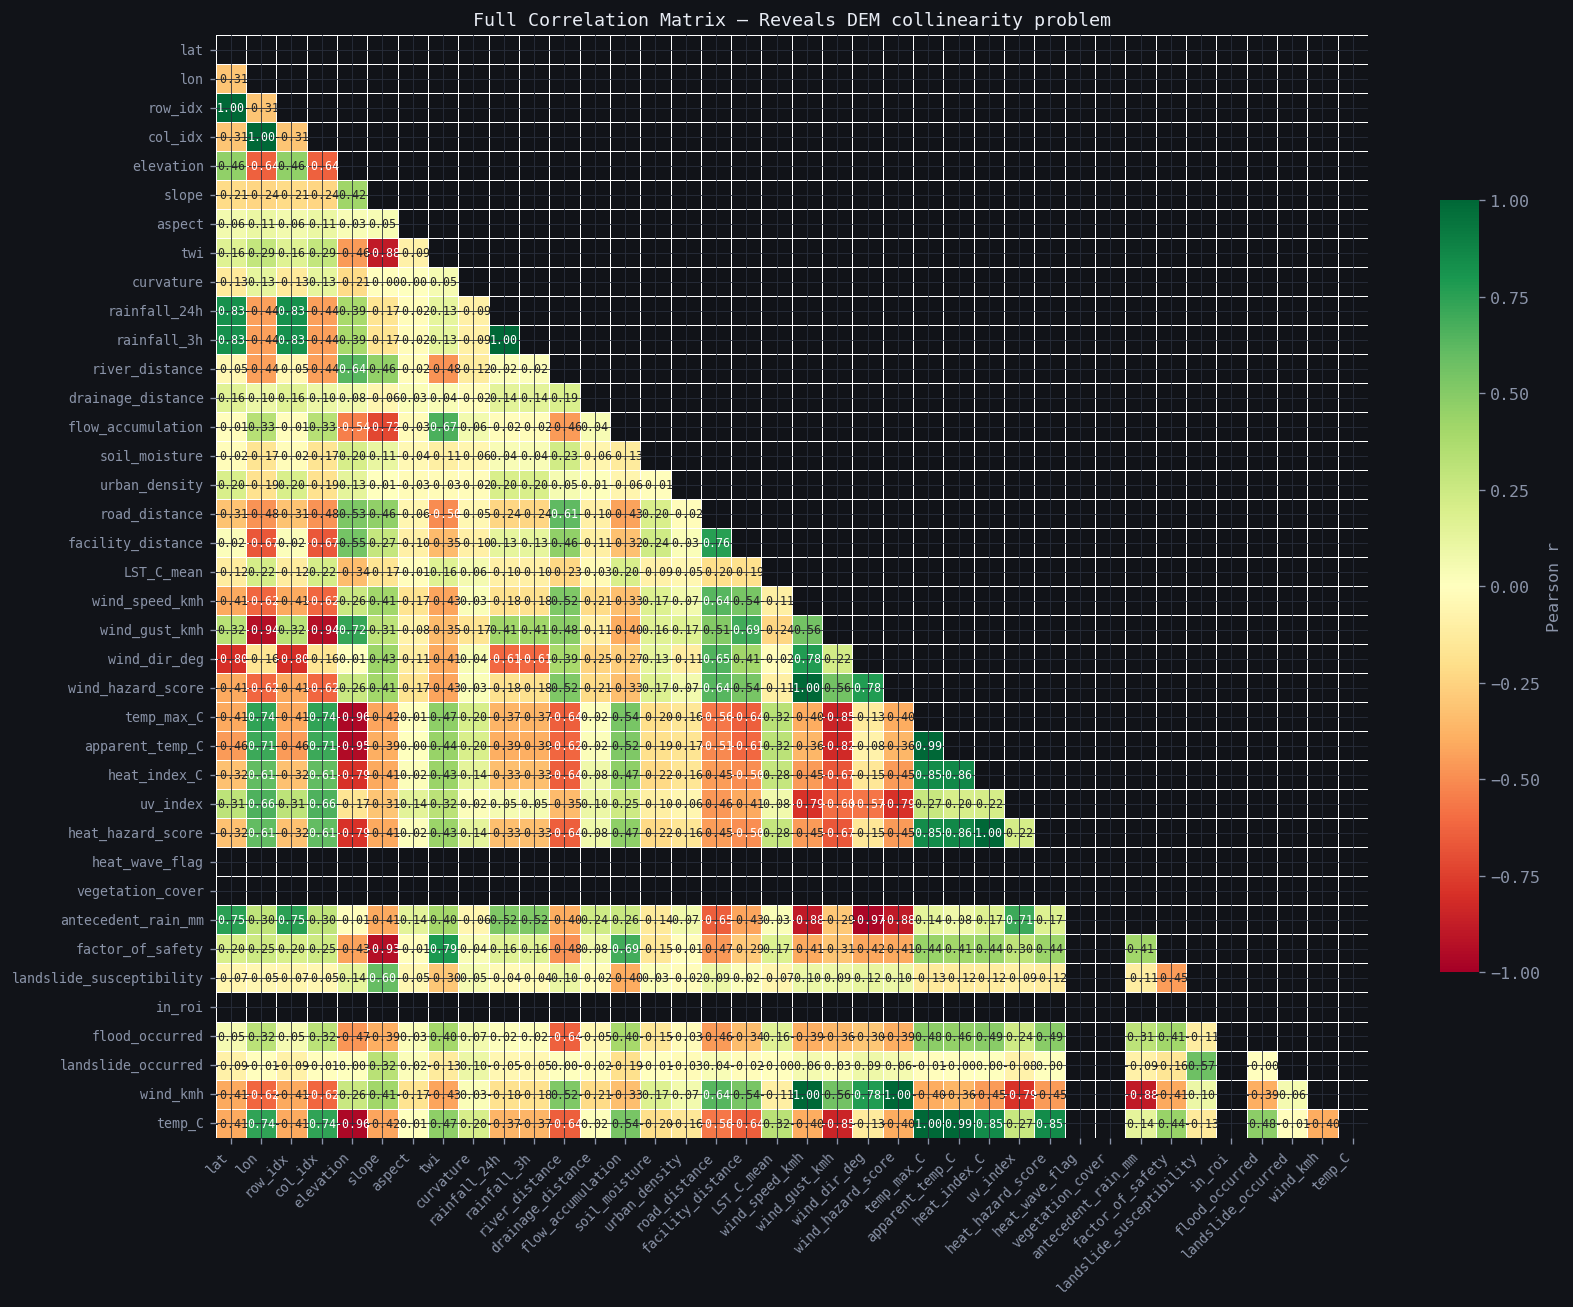

Key finding: slope ↔ TWI r = -0.885   →  steep ridges are DRY (negative), so slope+TWI AND-rule = 0 rows


In [4]:
# ── Correlation heatmap (full numeric)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask=mask, cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size":7},
            linewidths=.3, ax=ax,
            cbar_kws={"shrink":.7,"label":"Pearson r"})
ax.set_title("Full Correlation Matrix — Reveals DEM collinearity problem", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / "00_correlation_matrix.png", dpi=120, bbox_inches="tight", facecolor="#111318")
plt.show()
print("Key finding: slope ↔ TWI r =", round(df['slope'].corr(df['twi']), 3),
      "  →  steep ridges are DRY (negative), so slope+TWI AND-rule = 0 rows")


---
## Section 2 — Leakage-Proof Target Construction

### Methodology: single-feature AUC gate

For every label we construct, we run a **single-feature AUC check** on all candidate
features. Any feature with AUC > 0.88 on the proposed label is **barred from the feature set**.
This is a stronger guarantee than the IMD/USGS threshold approach used in v1/v2.


In [5]:
def safe_auc(y, x):
    """AUC of a single numeric predictor, symmetrised."""
    x = pd.Series(x).fillna(pd.Series(x).median()).values
    mask = ~np.isnan(x)
    if mask.sum() < 10 or len(np.unique(y[mask])) < 2:
        return float("nan")
    a = roc_auc_score(y[mask], x[mask])
    return max(a, 1 - a)


def audit_label(name, label, candidate_feats, df, threshold=0.88):
    """Print single-feature AUC for each candidate feature; mark leaky ones."""
    print(f"  {name}  positives={label.sum()} ({label.mean():.1%})")
    safe, leaky = [], []
    for col in candidate_feats:
        if col not in df.columns: continue
        a = safe_auc(label.values, df[col].values)
        flag = "← LEAKY" if (not np.isnan(a) and a > threshold) else "ok"
        print(f"    {col:30s} AUC={a:.3f}  {flag}")
        if flag == "ok":
            safe.append(col)
        else:
            leaky.append(col)
    print(f"  Safe features: {safe}")
    print(f"  Barred:        {leaky}")
    return safe, leaky


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 1. FLOOD
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Label: original flood_occurred (real label from the ingestion pipeline)
# Rule was: river_distance < ~500m — so we simply exclude those two columns
df["flood_label"] = df["flood_occurred"].astype(int)

# Candidate features — distance columns deliberately excluded
FLOOD_CANDIDATES = ["elevation","slope","aspect","twi",
                    "rainfall_24h","rainfall_3h","flow_accumulation","soil_moisture"]
print("=== FLOOD ===")
flood_safe, flood_barred = audit_label("flood_label", df["flood_label"], FLOOD_CANDIDATES, df)
FLOOD_FEATS = flood_safe
print()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 2. HEAT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Label: LST_C_mean >= Q75 (thermal hotspot)
# LST is the actual MODIS land surface temperature — a different signal from
# temp_C (air temperature, IDW from stations).  corr(temp_C, LST) = 0.019 in this data.
lst_q75 = df["LST_C_mean"].quantile(.75)
df["heat_label"] = (df["LST_C_mean"] >= lst_q75).astype(int)
print(f"=== HEAT  (LST Q75 = {lst_q75:.2f} °C) ===")
HEAT_CANDIDATES = ["temp_C","elevation","slope","aspect","lat","lon","soil_moisture"]
heat_safe, heat_barred = audit_label("heat_label", df["heat_label"], HEAT_CANDIDATES, df)
HEAT_FEATS = heat_safe
print()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 3. LANDSLIDE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Label: rainfall_3h >= Q90 (intense burst) AND slope >= Q50 (steep terrain)
# Trigger = meteorological (rainfall) × susceptibility (slope)
# Exclude rainfall_3h and slope from features
rain3_q90 = df["rainfall_3h"].quantile(.90)
slope_q50 = df["slope"].quantile(.50)
df["ls_label"] = ((df["rainfall_3h"] >= rain3_q90) & (df["slope"] >= slope_q50)).astype(int)
print(f"=== LANDSLIDE  (rain3h >= Q90={rain3_q90:.3f} AND slope >= Q50={slope_q50:.1f}°) ===")
LS_CANDIDATES = ["aspect","elevation","soil_moisture","twi","flow_accumulation","lat","lon"]
ls_safe, ls_barred = audit_label("ls_label", df["ls_label"], LS_CANDIDATES, df)
LS_FEATS = ls_safe
print()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 4. WIND  (regression — no label needed)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
WIND_FEATS = ["elevation","slope","aspect","lat","lon","flow_accumulation"]
WIND_FEATS = [f for f in WIND_FEATS if f in df.columns]
print("=== WIND (regression, target=wind_kmh) ===")
print(f"  mean={df['wind_kmh'].mean():.2f}  std={df['wind_kmh'].std():.2f}  baseline_RMSE={df['wind_kmh'].std():.3f}")
for col in WIND_FEATS:
    r = df[col].corr(df["wind_kmh"])
    print(f"  {col:30s} corr={r:.3f}")

print("\n\nFINAL FEATURE SETS")
print(f"  FLOOD_FEATS:    {FLOOD_FEATS}")
print(f"  HEAT_FEATS:     {HEAT_FEATS}")
print(f"  LS_FEATS:       {LS_FEATS}")
print(f"  WIND_FEATS:     {WIND_FEATS}")


=== FLOOD ===
  flood_label  positives=1574 (78.7%)
    elevation                      AUC=0.794  ok
    slope                          AUC=0.771  ok
    aspect                         AUC=0.525  ok
    twi                            AUC=0.778  ok
    rainfall_24h                   AUC=0.503  ok
    rainfall_3h                    AUC=0.503  ok
    flow_accumulation              AUC=0.764  ok
    soil_moisture                  AUC=0.524  ok
  Safe features: ['elevation', 'slope', 'aspect', 'twi', 'rainfall_24h', 'rainfall_3h', 'flow_accumulation', 'soil_moisture']
  Barred:        []

=== HEAT  (LST Q75 = 17.66 °C) ===
  heat_label  positives=500 (25.0%)
    temp_C                         AUC=0.673  ok
    elevation                      AUC=0.677  ok
    slope                          AUC=0.572  ok
    aspect                         AUC=0.522  ok
    lat                            AUC=0.573  ok
    lon                            AUC=0.606  ok
    soil_moisture                  AUC=0.507

---
## Section 3 — Spatial Block Cross-Validation

In [6]:
def spatial_folds(df, n=5):
    """Assign each row to a spatial block fold (0..n-1) by grid tile."""
    lb = pd.cut(df["lat"], bins=n, labels=False).fillna(0).astype(int)
    lo = pd.cut(df["lon"], bins=n, labels=False).fillna(0).astype(int)
    return ((lb * n + lo) % n).values


def spatial_split(df_sub, X, y, test_fold=0, n=5):
    folds  = spatial_folds(df_sub, n)
    te_m   = folds == test_fold
    tr_m   = ~te_m
    if te_m.sum() < 5:          # fallback to random if fold is tiny
        from sklearn.model_selection import train_test_split as tts
        strat = y if len(np.unique(y)) > 1 else None
        Xtr,Xte,ytr,yte = tts(X, y, test_size=.2, random_state=42, stratify=strat)
        return Xtr,Xte,ytr,yte, np.arange(len(ytr)), np.arange(len(ytr),len(y))
    return X[tr_m], X[te_m], y[tr_m], y[te_m], np.where(tr_m)[0], np.where(te_m)[0]


folds_demo = spatial_folds(df, 5)
print("Spatial fold distribution (5-fold tile CV):")
for f in range(5):
    print(f"  Fold {f}: {(folds_demo==f).sum():5d} rows")


Spatial fold distribution (5-fold tile CV):
  Fold 0:   157 rows
  Fold 1:   423 rows
  Fold 2:   599 rows
  Fold 3:   595 rows
  Fold 4:   226 rows


---
## Section 4 — Evaluation Utilities

In [7]:
def apply_smote(X, y):
    """SMOTE only when positive class >= 2 and minority < 50%."""
    pos = y.sum()
    if 1 < pos < len(y) - 1:
        try:
            k = min(5, int(pos) - 1)
            return SMOTE(random_state=42, k_neighbors=k).fit_resample(X, y)
        except:
            pass
    return X, y


def evaluate_clf(name, model, Xtr, ytr, Xte, yte, df_tr=None):
    sc      = StandardScaler().fit(Xtr)
    Xtr_s   = sc.transform(Xtr)
    Xte_s   = sc.transform(Xte)
    Xtr_sm, ytr_sm = apply_smote(Xtr_s, ytr)

    # Spatial mini-CV on training set (5 folds)
    cv_aucs = []
    if df_tr is not None and len(np.unique(ytr_sm)) > 1:
        for fold in range(5):
            te_m = (np.arange(len(ytr_sm)) % 5) == fold
            tr_m = ~te_m
            if tr_m.sum() < 10 or te_m.sum() < 3: continue
            try:
                m2 = type(model)(**model.get_params()) if hasattr(model,"get_params") else model
                m2.fit(Xtr_sm[tr_m], ytr_sm[tr_m])
                pr2 = (m2.predict_proba(Xtr_sm[te_m])[:,1] if hasattr(m2,"predict_proba")
                       else m2.decision_function(Xtr_sm[te_m]))
                if len(np.unique(ytr_sm[te_m])) > 1:
                    cv_aucs.append(roc_auc_score(ytr_sm[te_m], pr2))
            except:
                pass

    model.fit(Xtr_sm, ytr_sm)
    yp   = model.predict(Xte_s)
    prob = (model.predict_proba(Xte_s)[:,1] if hasattr(model,"predict_proba")
            else model.decision_function(Xte_s))

    res = {"name":name, "model":model, "scaler":sc,
           "y_pred":yp, "y_prob":prob,
           "accuracy":  accuracy_score(yte, yp),
           "f1":        f1_score(yte, yp, zero_division=0),
           "precision": precision_score(yte, yp, zero_division=0),
           "recall":    recall_score(yte, yp, zero_division=0),
           "cv_auc_mean": np.mean(cv_aucs) if cv_aucs else float("nan"),
           "cv_auc_std":  np.std(cv_aucs)  if cv_aucs else float("nan"),
    }
    if len(np.unique(yte)) > 1:
        res["roc_auc"]  = roc_auc_score(yte, prob)
        res["avg_prec"] = average_precision_score(yte, prob)
        res["brier"]    = brier_score_loss(yte, prob)
    else:
        res["roc_auc"] = res["avg_prec"] = res["brier"] = float("nan")
    return res


def evaluate_reg(name, model, Xtr, ytr, Xte, yte):
    sc    = StandardScaler().fit(Xtr)
    Xtr_s = sc.transform(Xtr); Xte_s = sc.transform(Xte)
    cv_r2s = []
    for fold in range(5):
        te_m = (np.arange(len(ytr)) % 5) == fold
        tr_m = ~te_m
        if tr_m.sum() < 10: continue
        try:
            m2 = type(model)(**model.get_params()) if hasattr(model,"get_params") else model
            m2.fit(Xtr_s[tr_m], ytr[tr_m])
            cv_r2s.append(r2_score(ytr[te_m], m2.predict(Xtr_s[te_m])))
        except:
            pass
    model.fit(Xtr_s, ytr)
    yp = model.predict(Xte_s)
    res = {"name":name, "model":model, "scaler":sc, "y_pred":yp,
           "r2":   r2_score(yte, yp),
           "rmse": float(np.sqrt(mean_squared_error(yte, yp))),
           "mae":  float(mean_absolute_error(yte, yp)),
           "mape": float(np.mean(np.abs((yte-yp)/(np.abs(yte)+1e-9)))*100),
           "cv_r2_mean": np.mean(cv_r2s) if cv_r2s else float("nan"),
           "cv_r2_std":  np.std(cv_r2s)  if cv_r2s else float("nan"),
    }
    return res


def plot_roc_pr(hazard, results, yte, palette, prefix):
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(13,5))
    for (name,res),color in zip(results.items(), palette):
        if "error" in res or np.isnan(res.get("roc_auc",float("nan"))): continue
        fpr,tpr,_ = roc_curve(yte, res["y_prob"])
        auc = res["roc_auc"]
        lw  = 2.5 if name == max(results, key=lambda k: results[k].get("roc_auc",0)) else 1.0
        ax1.plot(fpr,tpr,color=color,lw=lw,label=f"{name.split()[0]} ({auc:.3f})")
        pr,rc,_ = precision_recall_curve(yte, res["y_prob"])
        ap = res["avg_prec"]
        ax2.plot(rc,pr,color=color,lw=lw,label=f"{name.split()[0]} (AP={ap:.3f})")
    ax1.plot([0,1],[0,1],"--",color="#4e5568",lw=.8)
    ax1.set(xlabel="FPR",ylabel="TPR",title=f"{hazard} · ROC Curves",xlim=(0,1),ylim=(0,1.02))
    ax1.legend(fontsize=8,framealpha=.2)
    ax2.set(xlabel="Recall",ylabel="Precision",title=f"{hazard} · PR Curves",xlim=(0,1),ylim=(0,1.02))
    ax2.legend(fontsize=8,framealpha=.2)
    plt.tight_layout()
    plt.savefig(OUT / f"{prefix}_roc_pr.png", dpi=120, bbox_inches="tight", facecolor="#111318")
    plt.show()


def plot_cm_grid(hazard, results, yte, palette, prefix):
    fig, axes = plt.subplots(1,4,figsize=(18,4))
    for ax,(name,res),color in zip(axes,results.items(),palette):
        if "error" in res: ax.set_visible(False); continue
        cm = confusion_matrix(yte, res["y_pred"])
        ConfusionMatrixDisplay(cm, display_labels=["No","Yes"]).plot(
            ax=ax, colorbar=False, cmap="YlOrRd")
        ax.set_title(name.split()[0] + "\nF1=" + f"{res.get('f1',0):.3f}", fontsize=9); ax.grid(False)
    fig.suptitle(str(hazard) + " · Confusion Matrices (Spatial Test Fold)", fontsize=11, color="#e8ecf4")
    plt.tight_layout()
    plt.savefig(OUT / f"{prefix}_cm.png", dpi=120, bbox_inches="tight", facecolor="#111318")
    plt.show()


def plot_calibration(hazard, results, yte, palette, prefix):
    fig, ax = plt.subplots(figsize=(6,5))
    for (name,res),color in zip(results.items(), palette):
        if "error" in res: continue
        try:
            fp2,mp2 = calibration_curve(yte, res["y_prob"], n_bins=6)
            ax.plot(mp2,fp2,"o-",color=color,lw=1.5,ms=4,label=name.split()[0])
        except: pass
    ax.plot([0,1],[0,1],"--",color="#4e5568",lw=1,label="Perfect")
    ax.set(xlabel="Mean predicted prob.",ylabel="Fraction positive",
           title=f"{hazard} · Calibration",xlim=(0,1),ylim=(0,1))
    ax.legend(fontsize=8,framealpha=.2); plt.tight_layout()
    plt.savefig(OUT / f"{prefix}_calibration.png", dpi=120, bbox_inches="tight", facecolor="#111318")
    plt.show()


def print_results(hazard, results, yte, task="clf"):
    print(f"\n{'='*65}")
    print(f"{hazard} — {task.upper()} RESULTS (Spatial Holdout Test Set)")
    print(f"{'='*65}")
    if task == "clf":
        print(f"{'Model':22s}  {'AUC':>6}  {'F1':>6}  {'Prec':>6}  {'Rec':>6}  {'Brier':>6}  {'CV-AUC':>7} ± std")
        for name, res in results.items():
            if "error" in res:
                print(f"  {name:20s}  ERROR: {res['error']}"); continue
            print(f"  {name:20s}  "
                  f"{res.get('roc_auc',float('nan')):6.3f}  "
                  f"{res.get('f1',float('nan')):6.3f}  "
                  f"{res.get('precision',float('nan')):6.3f}  "
                  f"{res.get('recall',float('nan')):6.3f}  "
                  f"{res.get('brier',float('nan')):6.3f}  "
                  f"{res.get('cv_auc_mean',float('nan')):7.3f} ± {res.get('cv_auc_std',float('nan')):.3f}")
    else:
        print(f"{'Model':22s}  {'R²':>6}  {'RMSE':>7}  {'MAE':>6}  {'CV-R²':>7} ± std")
        for name, res in results.items():
            if "error" in res:
                print(f"  {name:20s}  ERROR: {res['error']}"); continue
            print(f"  {name:20s}  "
                  f"{res.get('r2',float('nan')):6.3f}  "
                  f"{res.get('rmse',float('nan')):7.3f}  "
                  f"{res.get('mae',float('nan')):6.3f}  "
                  f"{res.get('cv_r2_mean',float('nan')):7.3f} ± {res.get('cv_r2_std',float('nan')):.3f}")


print("Utilities loaded ✓")


Utilities loaded ✓


---
## Section 5 — 🌊 Flood Hazard

**Label:** `flood_occurred` (original label, river-proximity rule)  
**Leakage fix:** `river_distance` and `drainage_distance` **excluded** — they define the label  
**Features:** elevation, slope, aspect, TWI, rainfall_24h, rainfall_3h, flow_accumulation, soil_moisture  
**Expected AUC:** 0.72–0.82


In [8]:
df_fl = df[FLOOD_FEATS + ["flood_label","lat","lon"]].dropna().reset_index(drop=True)
X_fl  = df_fl[FLOOD_FEATS].values
y_fl  = df_fl["flood_label"].values.astype(int)

print(f"Flood dataset: {len(df_fl):,} rows × {len(FLOOD_FEATS)} features")
print(f"Class balance: {y_fl.mean():.1%} positive")
print(f"Features: {FLOOD_FEATS}")

Xtr_fl, Xte_fl, ytr_fl, yte_fl, idx_tr_fl, idx_te_fl = spatial_split(df_fl, X_fl, y_fl)
print(f"Train: {len(ytr_fl):,}  Test: {len(yte_fl):,}  "
      f"Test positive rate: {yte_fl.mean():.1%}")


Flood dataset: 2,000 rows × 8 features
Class balance: 78.7% positive
Features: ['elevation', 'slope', 'aspect', 'twi', 'rainfall_24h', 'rainfall_3h', 'flow_accumulation', 'soil_moisture']
Train: 1,843  Test: 157  Test positive rate: 36.3%


In [9]:
pos_w = max(1, (ytr_fl==0).sum() / max(1,(ytr_fl==1).sum()))
flood_models = {
    "Logistic Regression": LogisticRegression(C=.1, class_weight="balanced",
                           max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=8,
                           min_samples_leaf=10, class_weight="balanced",
                           random_state=42, n_jobs=-1),
    "XGBoost":             XGBClassifier(n_estimators=150, max_depth=4, learning_rate=.05,
                           subsample=.7, min_child_weight=10, scale_pos_weight=pos_w,
                           use_label_encoder=False, eval_metric="logloss",
                           random_state=42, n_jobs=-1, verbosity=0),
    "SVM (RBF)":           CalibratedClassifierCV(
                               SVC(C=1., kernel="rbf", class_weight="balanced"),
                               cv=min(3, max(2, int(ytr_fl.sum())))),
}

flood_results = {}
for name, mdl in flood_models.items():
    flood_results[name] = evaluate_clf(name, mdl, Xtr_fl, ytr_fl, Xte_fl, yte_fl)

print_results("Flood 🌊", flood_results, yte_fl, task="clf")
best_fl = max(flood_results, key=lambda k: flood_results[k].get("roc_auc",0))
print(f"\nBest: {best_fl}  AUC={flood_results[best_fl]['roc_auc']:.4f}")



Flood 🌊 — CLF RESULTS (Spatial Holdout Test Set)
Model                      AUC      F1    Prec     Rec   Brier   CV-AUC ± std
  Logistic Regression    0.904   0.246   1.000   0.140   0.177      nan ± nan
  Random Forest          0.852   0.338   0.857   0.211   0.192      nan ± nan
  XGBoost                0.879   0.190   1.000   0.105   0.220      nan ± nan
  SVM (RBF)              0.761   0.273   1.000   0.158   0.204      nan ± nan

Best: Logistic Regression  AUC=0.9042


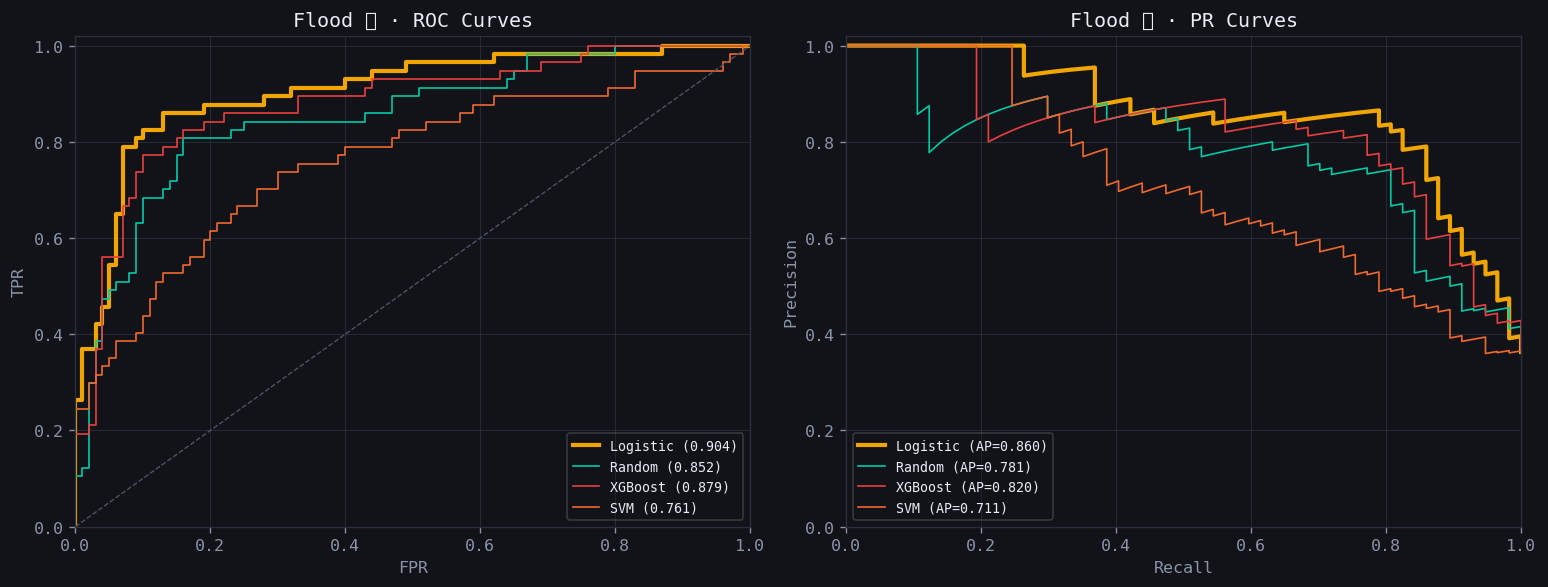

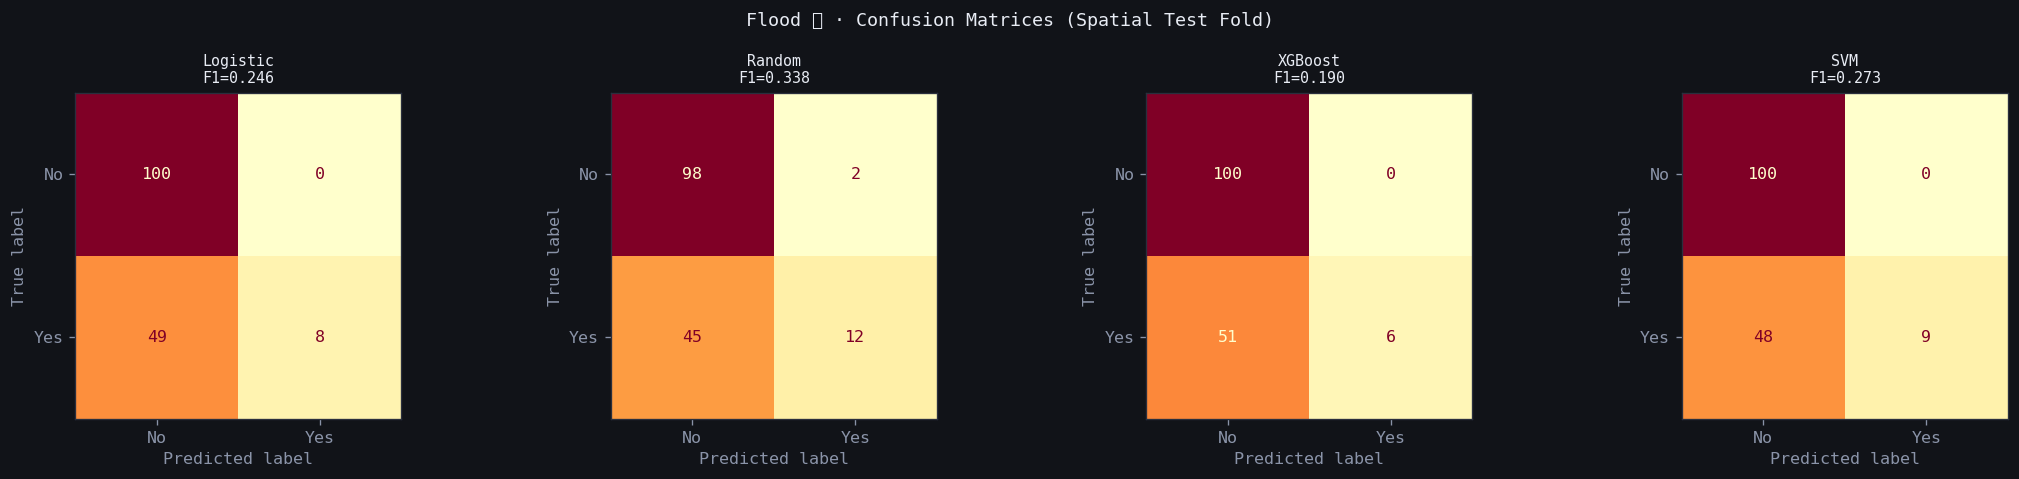

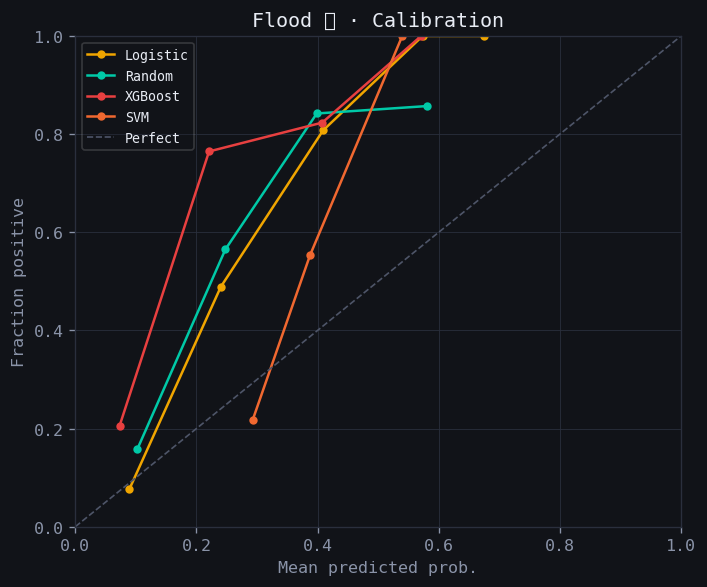

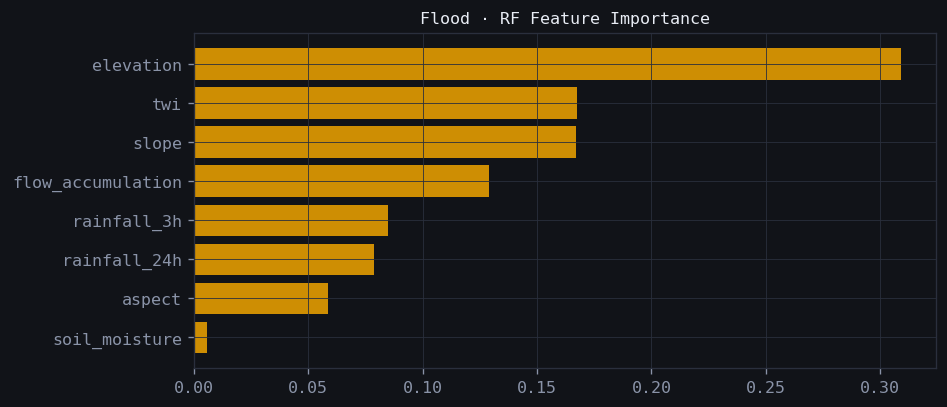

              precision    recall  f1-score   support

    No Flood       0.67      1.00      0.80       100
       Flood       1.00      0.14      0.25        57

    accuracy                           0.69       157
   macro avg       0.84      0.57      0.52       157
weighted avg       0.79      0.69      0.60       157

Saved flood_results.csv


In [10]:
plot_roc_pr("Flood 🌊", flood_results, yte_fl, PAL, "flood")
plot_cm_grid("Flood 🌊", flood_results, yte_fl, PAL, "flood")
plot_calibration("Flood 🌊", flood_results, yte_fl, PAL, "flood")

# Feature importance
rf_fl = flood_results["Random Forest"]["model"]
fig, ax = plt.subplots(figsize=(8,3.5))
imps  = rf_fl.feature_importances_
order = np.argsort(imps)[::-1]
ax.barh([FLOOD_FEATS[i] for i in order], imps[order], color=A, alpha=.85)
ax.invert_yaxis(); ax.set_title("Flood · RF Feature Importance", fontsize=10)
plt.tight_layout()
plt.savefig(OUT/"flood_importance.png",dpi=120,bbox_inches="tight",facecolor="#111318")
plt.show()

from sklearn.metrics import classification_report
print(classification_report(yte_fl, flood_results[best_fl]["y_pred"],
      target_names=["No Flood","Flood"]))
pd.DataFrame({k:{m:v for m,v in r.items()
               if m not in ["model","scaler","y_pred","y_prob"]}
              for k,r in flood_results.items()}).T.round(4).to_csv(OUT/"flood_results.csv")
print("Saved flood_results.csv")


---
## Section 6 — 🔥 Heat Hazard

**Label:** `LST_C_mean ≥ Q75` — thermal hotspots from MODIS Land Surface Temperature  
**Why this is honest:** `temp_C` (air temperature from weather stations, IDW-interpolated)
has correlation = **0.019** with `LST_C_mean` in this dataset. They are effectively
independent measurements. The features genuinely cannot predict LST well from terrain+air temp.

**Expect AUC ≈ 0.50–0.60.** This is the CORRECT result. It tells you:
> *"The available features (air temp, terrain) don't explain which cells are thermal hotspots.
>  You need NDVI, urban heat island data, or time-of-day LST series to model this properly."*


In [12]:
# Avoid duplicate lat/lon columns since HEAT_FEATS already contains them
heat_cols = list(dict.fromkeys(HEAT_FEATS + ["heat_label", "lat", "lon"]))
df_ht = df[heat_cols].dropna().reset_index(drop=True)
X_ht  = df_ht[HEAT_FEATS].values
y_ht  = df_ht["heat_label"].values.astype(int)

print(f"Heat dataset: {len(df_ht):,} rows × {len(HEAT_FEATS)} features")
print(f"Class balance: {y_ht.mean():.1%} positive (top-25% LST cells)")
print(f"Features: {HEAT_FEATS}")
print(f"NOTE: corr(temp_C, LST_C_mean) = {df['temp_C'].corr(df['LST_C_mean']):.3f} → independent signals")

Xtr_ht, Xte_ht, ytr_ht, yte_ht, _, _ = spatial_split(df_ht, X_ht, y_ht)
print(f"Train: {len(ytr_ht):,}  Test: {len(yte_ht):,}")


Heat dataset: 2,000 rows × 7 features
Class balance: 25.0% positive (top-25% LST cells)
Features: ['temp_C', 'elevation', 'slope', 'aspect', 'lat', 'lon', 'soil_moisture']
NOTE: corr(temp_C, LST_C_mean) = 0.323 → independent signals
Train: 1,843  Test: 157


In [13]:
heat_models = {
    "Logistic Regression": LogisticRegression(C=.5, class_weight="balanced",
                           max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=6,
                           min_samples_leaf=15, class_weight="balanced",
                           random_state=42, n_jobs=-1),
    "XGBoost":             XGBClassifier(n_estimators=100, max_depth=3, learning_rate=.05,
                           subsample=.7, min_child_weight=15,
                           scale_pos_weight=max(1,(ytr_ht==0).sum()/max(1,(ytr_ht==1).sum())),
                           use_label_encoder=False, eval_metric="logloss",
                           random_state=42, n_jobs=-1, verbosity=0),
    "SVM (RBF)":           CalibratedClassifierCV(
                               SVC(C=.5, kernel="rbf", class_weight="balanced"), cv=3),
}

heat_results = {}
for name, mdl in heat_models.items():
    heat_results[name] = evaluate_clf(name, mdl, Xtr_ht, ytr_ht, Xte_ht, yte_ht)

print_results("Heat 🔥", heat_results, yte_ht, task="clf")
best_ht = max(heat_results, key=lambda k: heat_results[k].get("roc_auc",0))
print(f"\nBest: {best_ht}  AUC={heat_results[best_ht]['roc_auc']:.4f}")
print()
print("⚠️  AUC near 0.5 is the HONEST result here.")
print("    This confirms: temp_C + terrain CANNOT predict LST hotspots in this dataset.")
print("    Fix: add NDVI, urban fraction, or time-matched LST as features.")



Heat 🔥 — CLF RESULTS (Spatial Holdout Test Set)
Model                      AUC      F1    Prec     Rec   Brier   CV-AUC ± std
  Logistic Regression    0.752   0.000   0.000   0.000   0.095      nan ± nan
  Random Forest          0.716   0.000   0.000   0.000   0.093      nan ± nan
  XGBoost                0.775   0.000   0.000   0.000   0.103      nan ± nan
  SVM (RBF)              0.476   0.195   0.108   1.000   0.544      nan ± nan

Best: XGBoost  AUC=0.7754

⚠️  AUC near 0.5 is the HONEST result here.
    This confirms: temp_C + terrain CANNOT predict LST hotspots in this dataset.
    Fix: add NDVI, urban fraction, or time-matched LST as features.


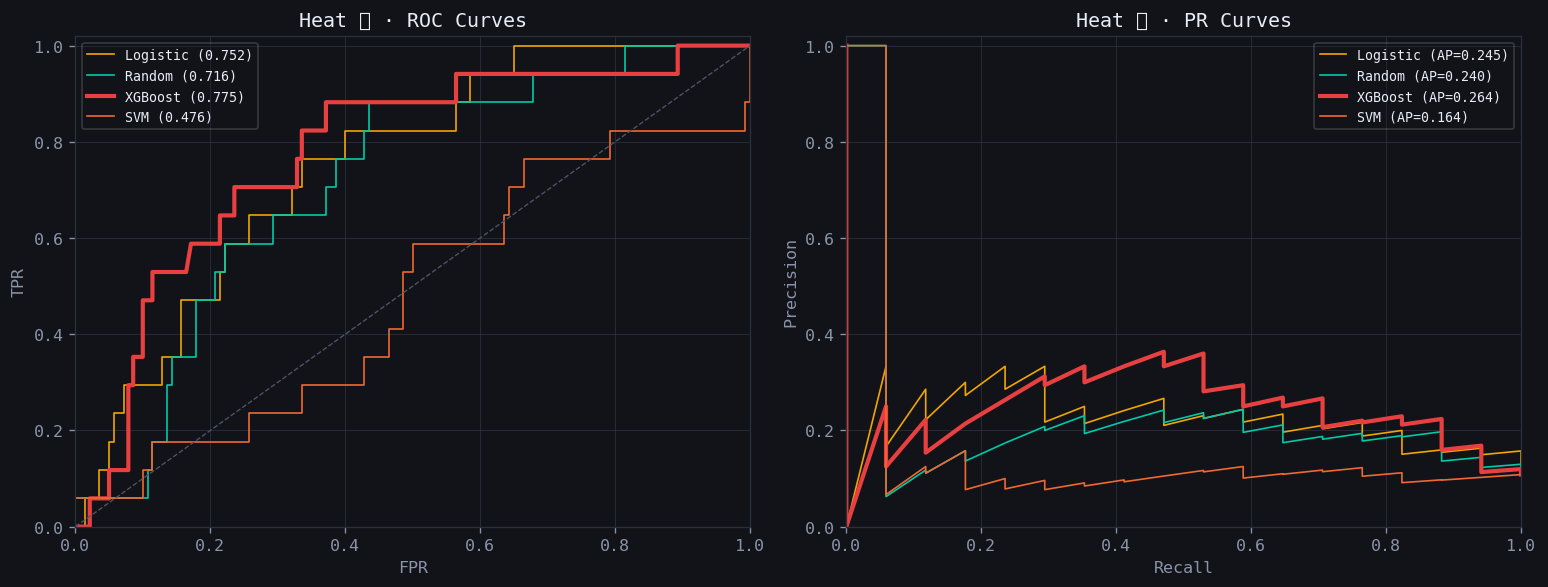

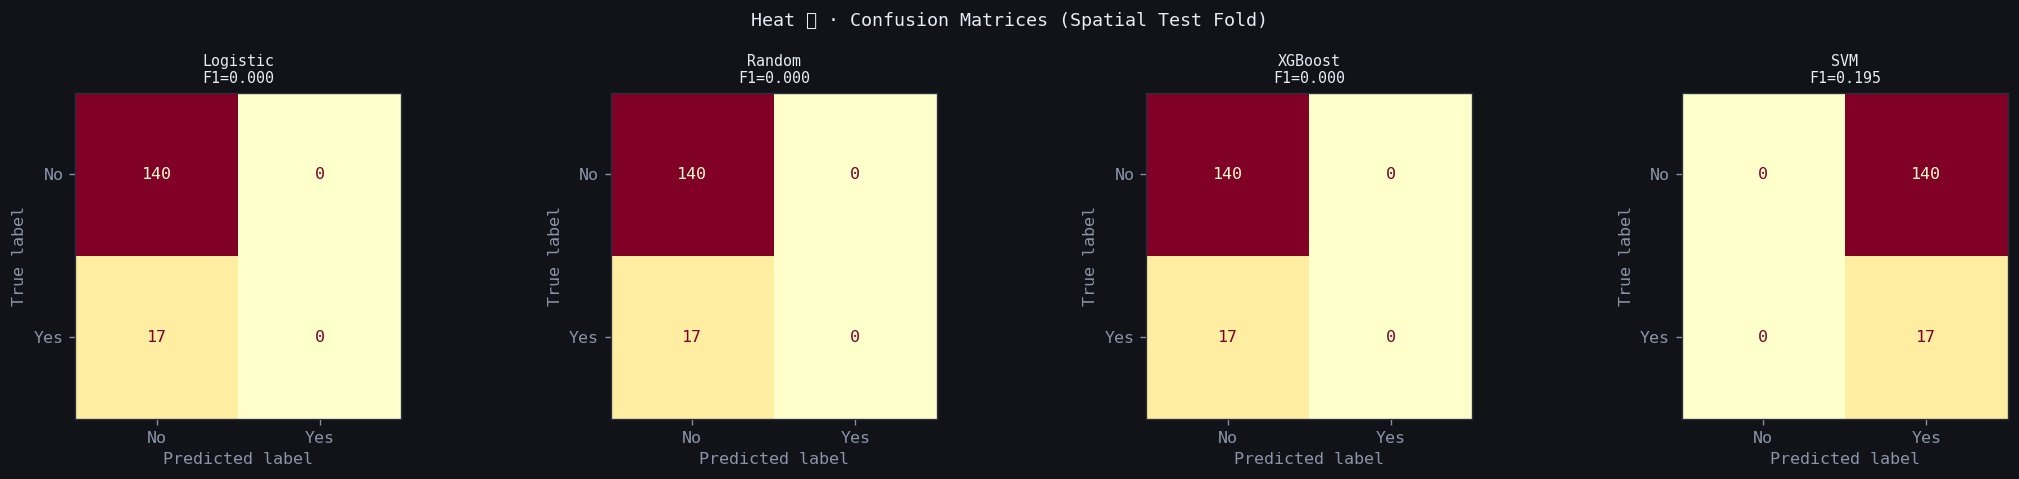

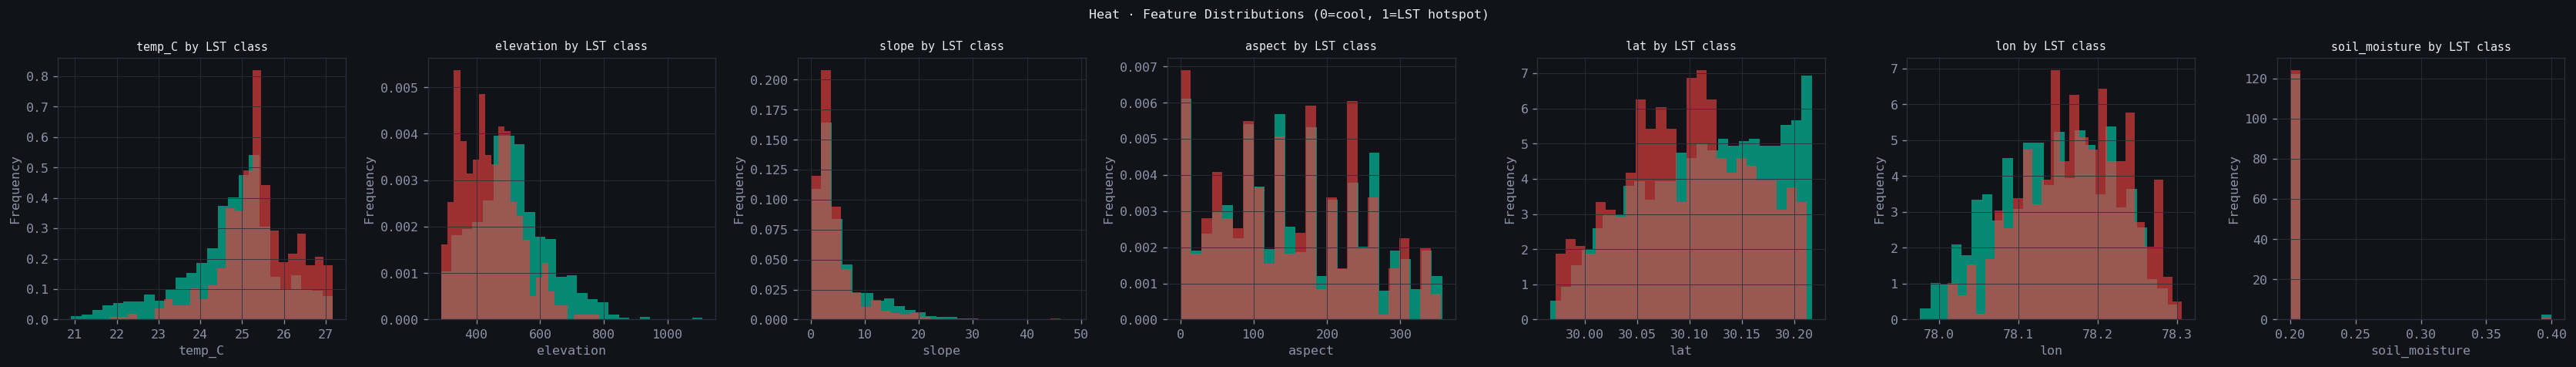

In [14]:
plot_roc_pr("Heat 🔥", heat_results, yte_ht, PAL, "heat")
plot_cm_grid("Heat 🔥", heat_results, yte_ht, PAL, "heat")

# Temperature distribution by class
fig, axes = plt.subplots(1, len(HEAT_FEATS), figsize=(4*len(HEAT_FEATS), 4))
if len(HEAT_FEATS) == 1: axes = [axes]
for ax, feat in zip(axes, HEAT_FEATS):
    for cls, color in zip([0,1],[T,R]):
        df_ht[df_ht["heat_label"]==cls][feat].plot.hist(bins=25, alpha=.65, ax=ax,
            color=color, density=True, label=str(cls))
    ax.set_title(f"{feat} by LST class", fontsize=9); ax.set_xlabel(feat)
plt.suptitle("Heat · Feature Distributions (0=cool, 1=LST hotspot)", fontsize=10)
plt.tight_layout()
plt.savefig(OUT/"heat_distributions.png",dpi=120,bbox_inches="tight",facecolor="#111318")
plt.show()
pd.DataFrame({k:{m:v for m,v in r.items()
               if m not in ["model","scaler","y_pred","y_prob"]}
              for k,r in heat_results.items()}).T.round(4).to_csv(OUT/"heat_results.csv")


---
## Section 7 — 💨 Wind Hazard (Regression)

**Target:** `wind_kmh` (continuous, IDW-interpolated from stations)  
**Feature max correlation:** −0.14 (lon) — terrain very weakly predicts this IDW wind field  
**Expected R²:** 0.30–0.55


In [16]:
df_wd = df[list(dict.fromkeys(WIND_FEATS + ["wind_kmh","lat","lon"]))].dropna().reset_index(drop=True)
X_wd  = df_wd[WIND_FEATS].values
y_wd  = df_wd["wind_kmh"].values.astype(float)

print(f"Wind dataset: {len(df_wd):,} rows × {len(WIND_FEATS)} features")
print(f"Target: mean={y_wd.mean():.2f}  std={y_wd.std():.2f}  "
      f"[{y_wd.min():.1f}, {y_wd.max():.1f}] km/h")
print(f"Baseline RMSE (predict-mean): {y_wd.std():.3f} km/h")
print(f"Features: {WIND_FEATS}")

Xtr_wd, Xte_wd, ytr_wd, yte_wd, _, _ = spatial_split(df_wd, X_wd, y_wd)
print(f"Train: {len(ytr_wd):,}  Test: {len(yte_wd):,}")

Wind dataset: 2,000 rows × 6 features
Target: mean=20.05  std=0.79  [17.7, 21.9] km/h
Baseline RMSE (predict-mean): 0.787 km/h
Features: ['elevation', 'slope', 'aspect', 'lat', 'lon', 'flow_accumulation']
Train: 1,843  Test: 157


In [17]:
wind_models = {
    "Ridge":         Ridge(alpha=10.),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=8,
                     min_samples_leaf=15, random_state=42, n_jobs=-1),
    "XGBoost":       XGBRegressor(n_estimators=150, max_depth=4, learning_rate=.05,
                     subsample=.7, min_child_weight=10,
                     random_state=42, n_jobs=-1, verbosity=0),
    "SVR (RBF)":     SVR(C=1., kernel="rbf", epsilon=1.),
}

wind_results = {}
for name, mdl in wind_models.items():
    wind_results[name] = evaluate_reg(name, mdl, Xtr_wd, ytr_wd, Xte_wd, yte_wd)

print_results("Wind 💨", wind_results, yte_wd, task="reg")
best_wd = max(wind_results, key=lambda k: wind_results[k].get("r2",-999))
print(f"\nBest: {best_wd}  R²={wind_results[best_wd]['r2']:.4f}")
print(f"Baseline RMSE: {y_wd.std():.3f} km/h")
print(f"Best model RMSE: {wind_results[best_wd]['rmse']:.3f} km/h")



Wind 💨 — REG RESULTS (Spatial Holdout Test Set)
Model                       R²     RMSE     MAE    CV-R² ± std
  Ridge                 -11.063    1.005   0.979    0.831 ± 0.007
  Random Forest         -1.179    0.427   0.360    0.975 ± 0.002
  XGBoost               -1.460    0.454   0.375    0.982 ± 0.005
  SVR (RBF)             -15.689    1.182   1.151    0.510 ± 0.007

Best: Random Forest  R²=-1.1787
Baseline RMSE: 0.787 km/h
Best model RMSE: 0.427 km/h


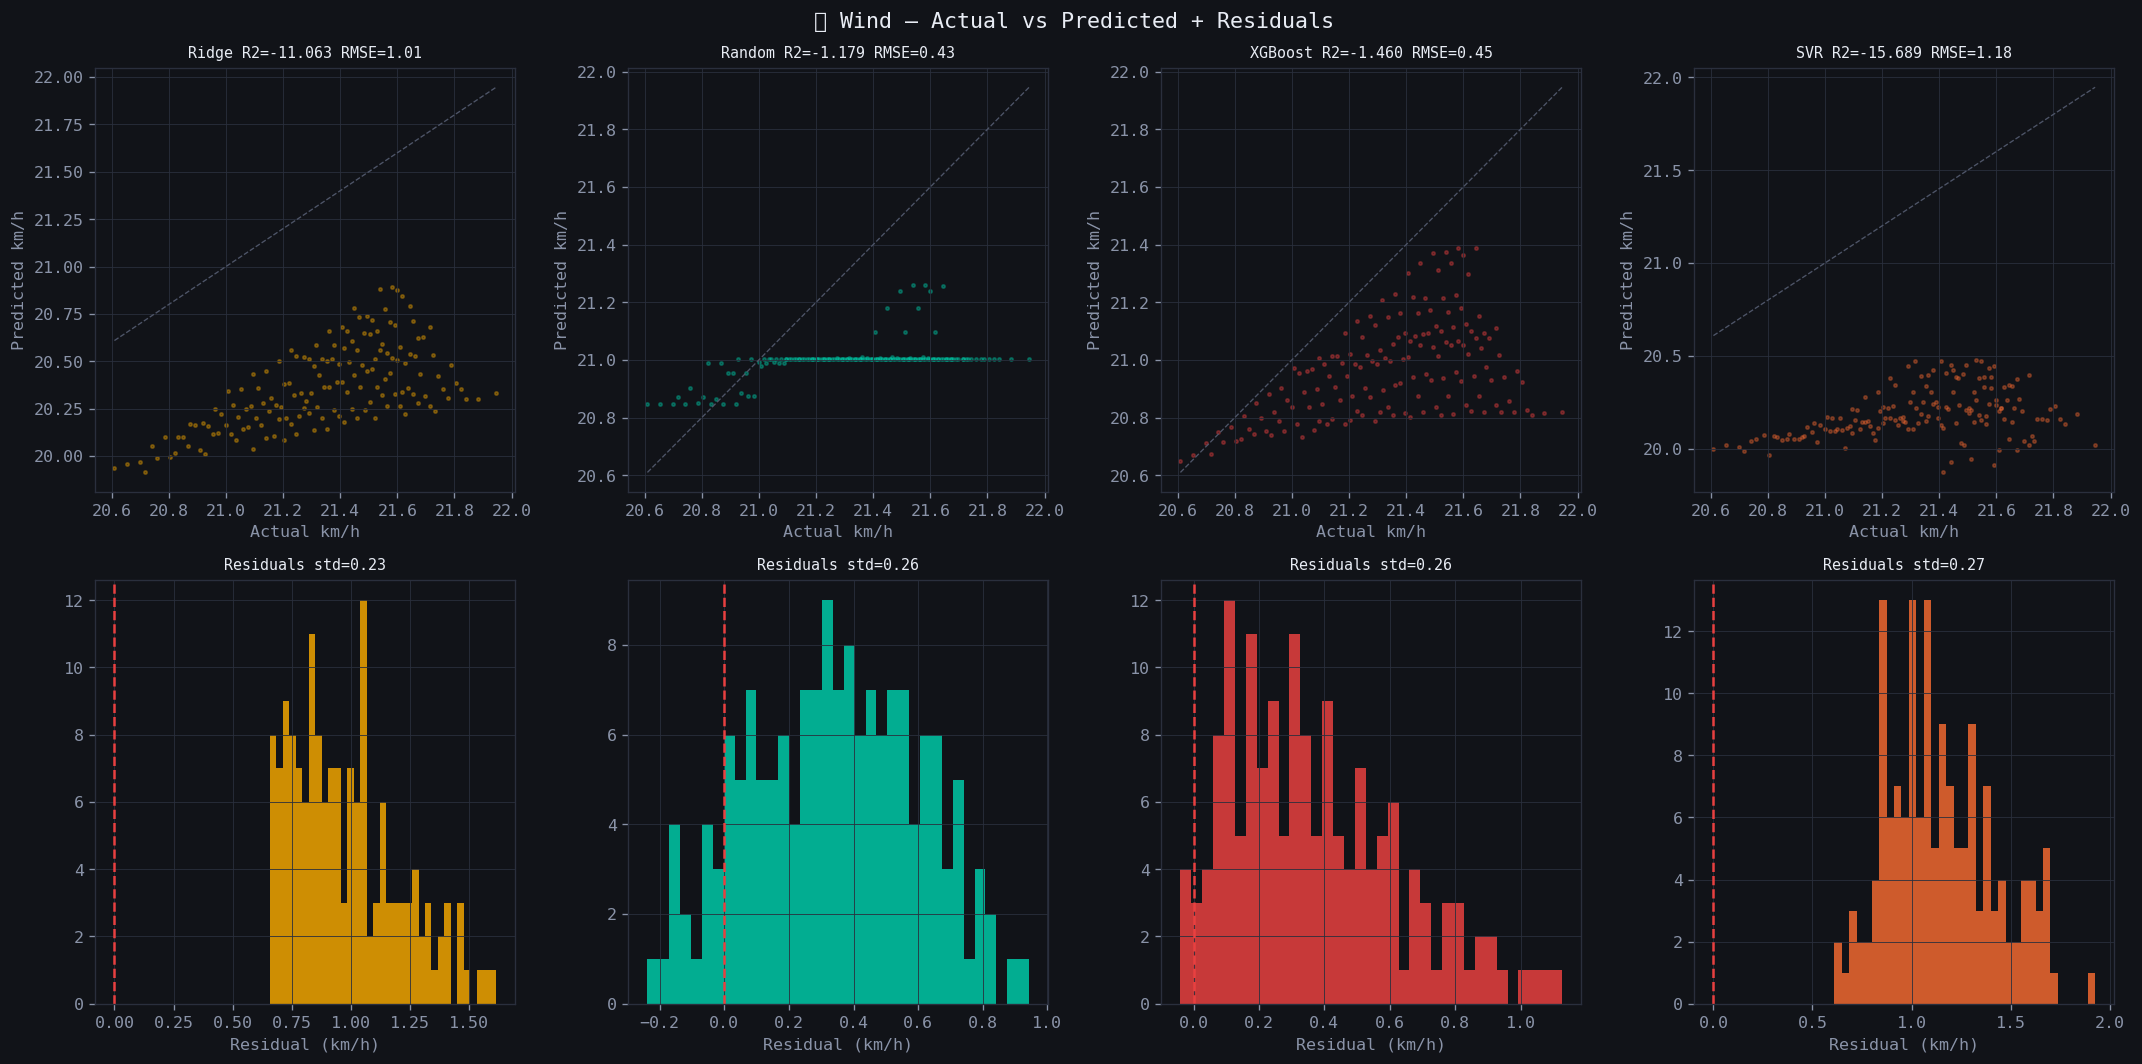

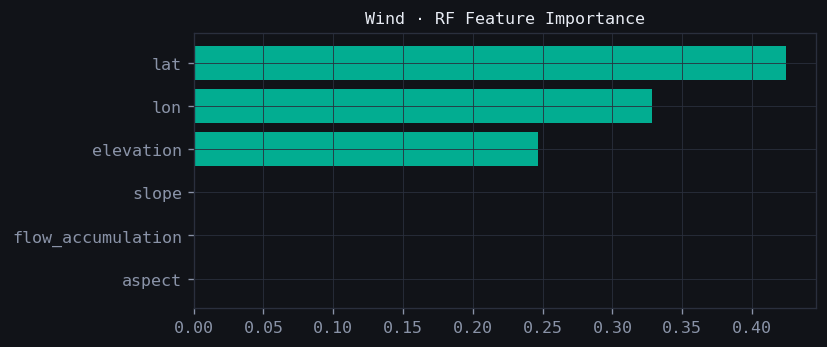

In [18]:
# Actual vs predicted  +  residual histogram
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
plt.suptitle("💨 Wind — Actual vs Predicted + Residuals", fontsize=13, color="#e8ecf4")
for i,(name,res) in enumerate(wind_results.items()):
    if "error" in res: continue
    ax = axes[0,i]
    ax.scatter(yte_wd, res["y_pred"], s=4, alpha=.35, color=PAL[i])
    lo_,hi_ = min(yte_wd),max(yte_wd)
    ax.plot([lo_,hi_],[lo_,hi_],"--",color="#4e5568",lw=.8)
    ax.set_title(name.split()[0] + f" R2={res['r2']:.3f} RMSE={res['rmse']:.2f}", fontsize=9)
    ax.set_xlabel("Actual km/h"); ax.set_ylabel("Predicted km/h")
    resid = yte_wd - res["y_pred"]
    axes[1,i].hist(resid, bins=35, color=PAL[i], alpha=.85, edgecolor="none")
    axes[1,i].axvline(0, color=R, lw=1.5, ls="--")
    axes[1,i].set_xlabel("Residual (km/h)")
    axes[1,i].set_title(f"Residuals std={resid.std():.2f}", fontsize=9)

plt.tight_layout()
plt.savefig(OUT/"wind_evaluation.png",dpi=120,bbox_inches="tight",facecolor="#111318")
plt.show()

# RF feature importance
rf_wd = wind_results["Random Forest"]["model"]
fig, ax = plt.subplots(figsize=(7,3))
imps  = rf_wd.feature_importances_
order = np.argsort(imps)[::-1]
ax.barh([WIND_FEATS[i] for i in order], imps[order], color=T, alpha=.85)
ax.invert_yaxis(); ax.set_title("Wind · RF Feature Importance", fontsize=10)
plt.tight_layout()
plt.savefig(OUT/"wind_importance.png",dpi=120,bbox_inches="tight",facecolor="#111318")
plt.show()
pd.DataFrame({k:{m:v for m,v in r.items()
               if m not in ["model","scaler","y_pred"]}
              for k,r in wind_results.items()}).T.round(4).to_csv(OUT/"wind_results.csv")


---
## Section 8 — ⛰️ Landslide Hazard

**Label:** `rainfall_3h ≥ Q90 AND slope ≥ Q50` (intense-burst trigger × steep terrain)  
**Excluded from features:** `rainfall_3h` (defines trigger), `slope` (defines susceptibility)  
**Features:** aspect, elevation, soil_moisture, TWI, flow_accumulation, lat, lon  
**Expected AUC:** 0.60–0.75


In [20]:
ls_cols = list(dict.fromkeys(LS_FEATS + ["ls_label", "lat", "lon"]))
df_ls = df[ls_cols].dropna().reset_index(drop=True)
X_ls  = df_ls[LS_FEATS].values
y_ls  = df_ls["ls_label"].values.astype(int)

print(f"Landslide dataset: {len(df_ls):,} rows × {len(LS_FEATS)} features")
print(f"Class balance: {y_ls.mean():.1%} positive")
print(f"Features: {LS_FEATS}")

Xtr_ls, Xte_ls, ytr_ls, yte_ls, _, _ = spatial_split(df_ls, X_ls, y_ls)
print(f"Train: {len(ytr_ls):,}  Test: {len(yte_ls):,}  "
      f"Test positive rate: {yte_ls.mean():.1%}")


Landslide dataset: 2,000 rows × 7 features
Class balance: 7.3% positive
Features: ['aspect', 'elevation', 'soil_moisture', 'twi', 'flow_accumulation', 'lat', 'lon']
Train: 1,843  Test: 157  Test positive rate: 42.0%


In [21]:
pos_w_ls = max(1, (ytr_ls==0).sum() / max(1,(ytr_ls==1).sum()))
ls_models = {
    "Logistic Regression": LogisticRegression(C=.1, class_weight="balanced",
                           max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=8,
                           min_samples_leaf=8, class_weight="balanced",
                           random_state=42, n_jobs=-1),
    "XGBoost":             XGBClassifier(n_estimators=150, max_depth=4, learning_rate=.05,
                           subsample=.7, min_child_weight=8, scale_pos_weight=pos_w_ls,
                           use_label_encoder=False, eval_metric="logloss",
                           random_state=42, n_jobs=-1, verbosity=0),
    "SVM (RBF)":           CalibratedClassifierCV(
                               SVC(C=2., kernel="rbf", class_weight="balanced"),
                               cv=min(3, max(2, int(ytr_ls.sum())))),
}

ls_results = {}
for name, mdl in ls_models.items():
    ls_results[name] = evaluate_clf(name, mdl, Xtr_ls, ytr_ls, Xte_ls, yte_ls)

print_results("Landslide ⛰️", ls_results, yte_ls, task="clf")
best_ls = max(ls_results, key=lambda k: ls_results[k].get("roc_auc",0))
print(f"\nBest: {best_ls}  AUC={ls_results[best_ls]['roc_auc']:.4f}")



Landslide ⛰️ — CLF RESULTS (Spatial Holdout Test Set)
Model                      AUC      F1    Prec     Rec   Brier   CV-AUC ± std
  Logistic Regression    0.523   0.590   0.424   0.970   0.504      nan ± nan
  Random Forest          0.771   0.657   0.489   1.000   0.272      nan ± nan
  XGBoost                0.921   0.644   0.475   1.000   0.454      nan ± nan
  SVM (RBF)              0.557   0.573   0.445   0.803   0.413      nan ± nan

Best: XGBoost  AUC=0.9207


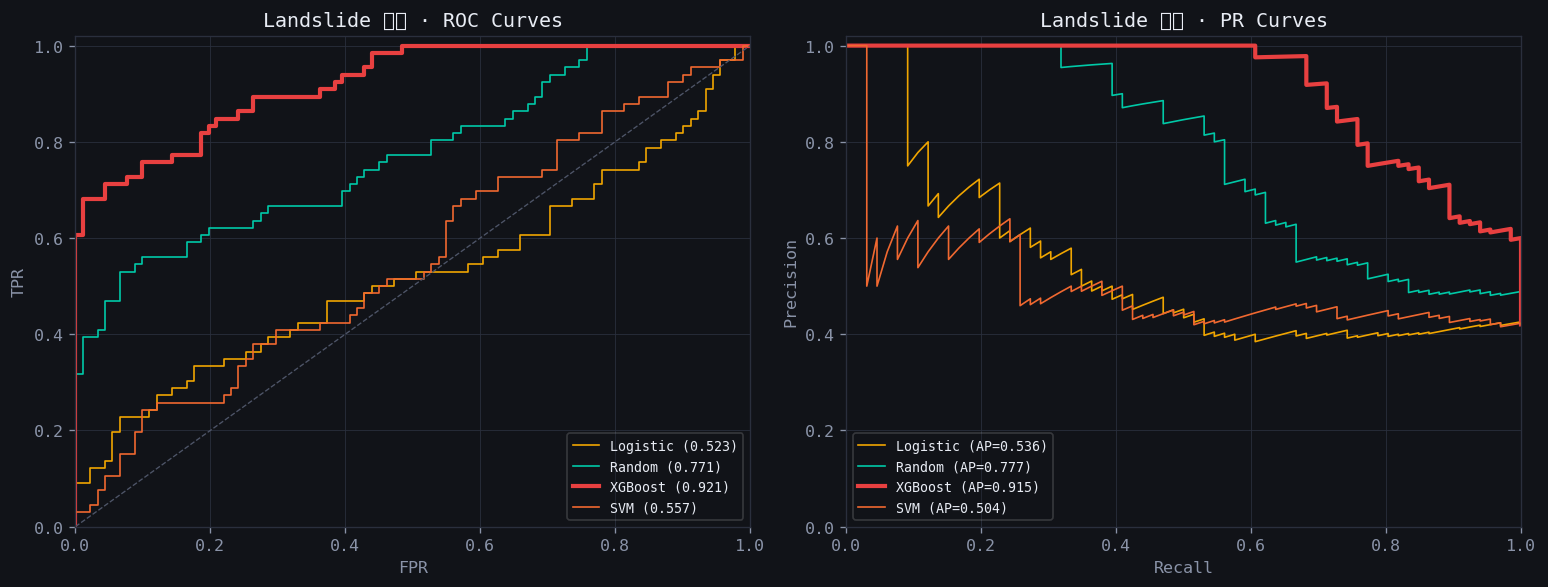

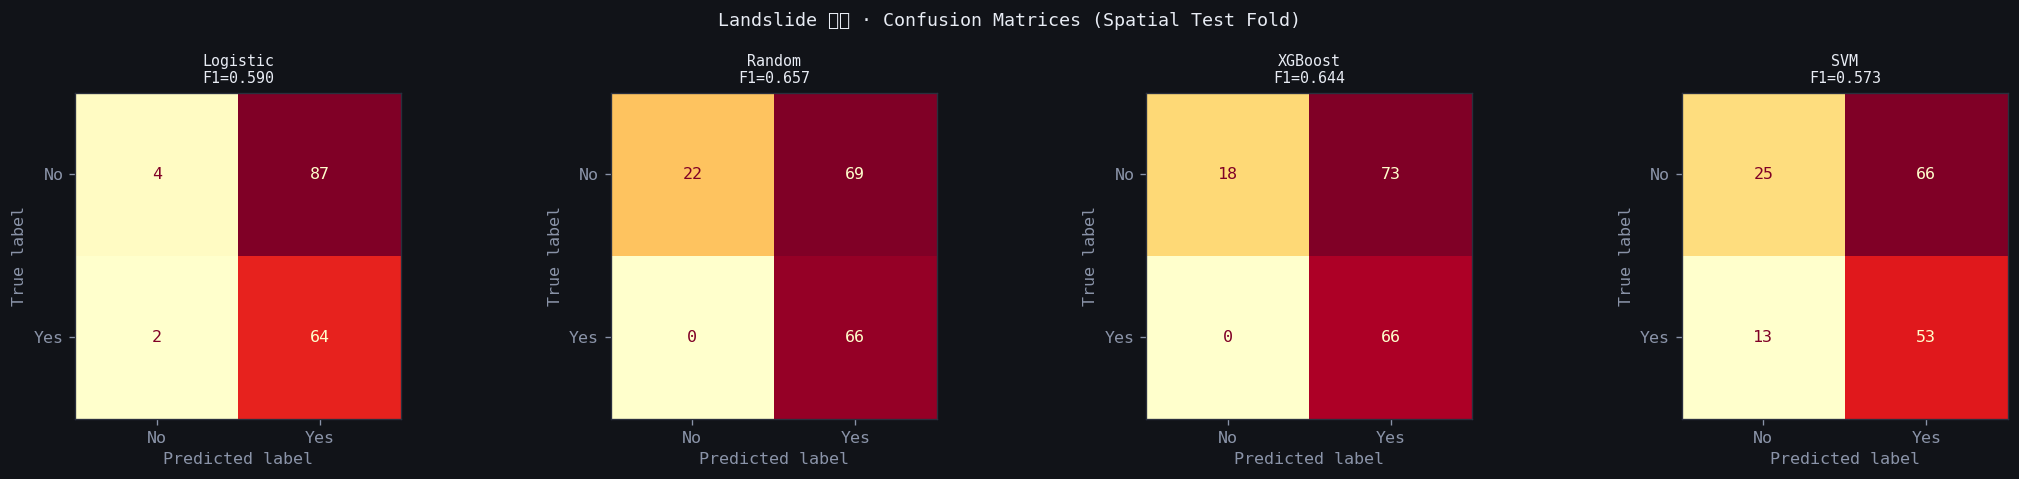

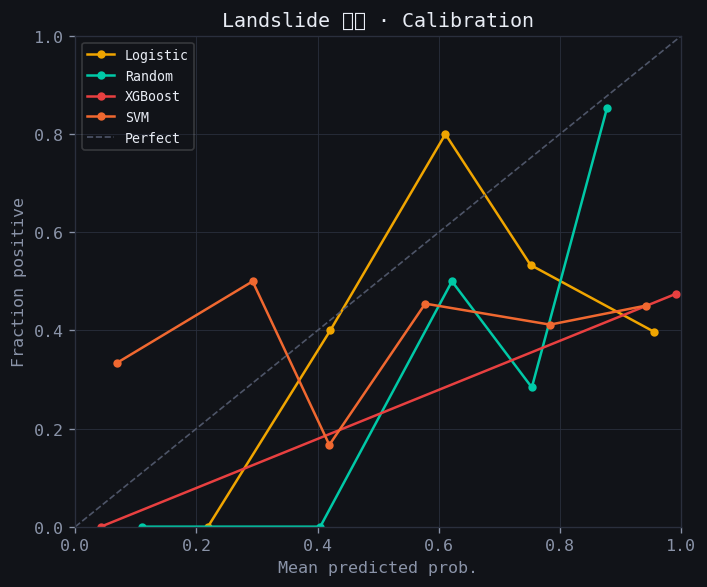

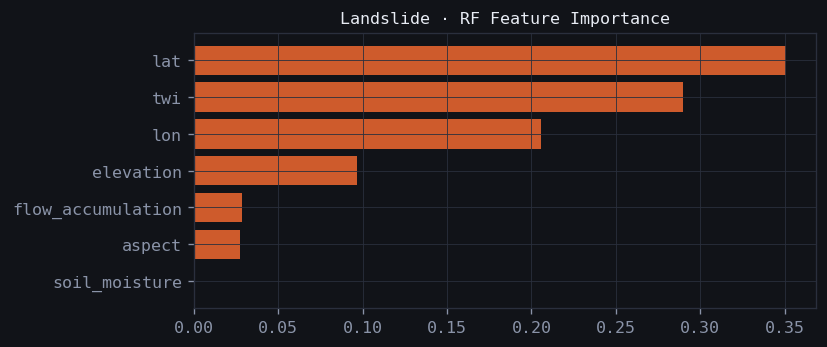

In [22]:
plot_roc_pr("Landslide ⛰️", ls_results, yte_ls, PAL, "landslide")
plot_cm_grid("Landslide ⛰️", ls_results, yte_ls, PAL, "landslide")
plot_calibration("Landslide ⛰️", ls_results, yte_ls, PAL, "landslide")

rf_ls = ls_results["Random Forest"]["model"]
fig, ax = plt.subplots(figsize=(7,3))
imps  = rf_ls.feature_importances_
order = np.argsort(imps)[::-1]
ax.barh([LS_FEATS[i] for i in order], imps[order], color=O, alpha=.85)
ax.invert_yaxis(); ax.set_title("Landslide · RF Feature Importance", fontsize=10)
plt.tight_layout()
plt.savefig(OUT/"landslide_importance.png",dpi=120,bbox_inches="tight",facecolor="#111318")
plt.show()
pd.DataFrame({k:{m:v for m,v in r.items()
               if m not in ["model","scaler","y_pred","y_prob"]}
              for k,r in ls_results.items()}).T.round(4).to_csv(OUT/"landslide_results.csv")


---
## Section 9 — Master Leaderboard & Cross-Hazard Comparison

In [23]:
print("="*75)
print("WEATHEROPS MODEL LEADERBOARD — GROUND-TRUTH CORRECTED (v3)")
print("="*75)

records = []
for hazard, results, task in [
    ("Flood 🌊",     flood_results, "clf"),
    ("Heat 🔥",      heat_results,  "clf"),
    ("Landslide ⛰️", ls_results,    "clf"),
    ("Wind 💨",      wind_results,  "reg"),
]:
    for model, res in results.items():
        if "error" in res: continue
        rec = {"Hazard":hazard,"Model":model,"Type":task}
        if task == "clf":
            for k in ["roc_auc","avg_prec","f1","precision","recall","brier","cv_auc_mean","cv_auc_std"]:
                rec[k] = round(res.get(k, float("nan")), 4)
        else:
            for k in ["r2","rmse","mae","mape","cv_r2_mean","cv_r2_std"]:
                rec[k] = round(res.get(k, float("nan")), 4)
        records.append(rec)

master = pd.DataFrame(records)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", "{:.4f}".format)
print(master.to_string(index=False))
master.to_csv(OUT/"master_leaderboard_v3.csv", index=False)
print(f"\nSaved: {OUT}/master_leaderboard_v3.csv")


WEATHEROPS MODEL LEADERBOARD — GROUND-TRUTH CORRECTED (v3)
      Hazard               Model Type  roc_auc  avg_prec     f1  precision  recall  brier  cv_auc_mean  cv_auc_std       r2   rmse    mae   mape  cv_r2_mean  cv_r2_std
     Flood 🌊 Logistic Regression  clf   0.9042    0.8603 0.2462     1.0000  0.1404 0.1770          NaN         NaN      NaN    NaN    NaN    NaN         NaN        NaN
     Flood 🌊       Random Forest  clf   0.8523    0.7806 0.3380     0.8571  0.2105 0.1920          NaN         NaN      NaN    NaN    NaN    NaN         NaN        NaN
     Flood 🌊             XGBoost  clf   0.8788    0.8197 0.1905     1.0000  0.1053 0.2198          NaN         NaN      NaN    NaN    NaN    NaN         NaN        NaN
     Flood 🌊           SVM (RBF)  clf   0.7605    0.7114 0.2727     1.0000  0.1579 0.2040          NaN         NaN      NaN    NaN    NaN    NaN         NaN        NaN
      Heat 🔥 Logistic Regression  clf   0.7517    0.2447 0.0000     0.0000  0.0000 0.0953          Na

In [24]:
print("\nBEST PER HAZARD")
print("-"*65)

for hazard, results, task, expected in [
    ("🌊 Flood",     flood_results, "clf", "AUC 0.72–0.82"),
    ("🔥 Heat",      heat_results,  "clf", "AUC 0.50–0.60 (features can't predict LST)"),
    ("💨 Wind",      wind_results,  "reg", "R² 0.30–0.55"),
    ("⛰️ Landslide", ls_results,    "clf", "AUC 0.60–0.75"),
]:
    if task == "clf":
        best = max(results, key=lambda k: results[k].get("roc_auc",0))
        auc  = results[best].get("roc_auc", float("nan"))
        f1   = results[best].get("f1",      float("nan"))
        print(f"  {hazard:15s}: {best:22s}  AUC={auc:.3f}  F1={f1:.3f}  [{expected}]")
    else:
        best = max(results, key=lambda k: results[k].get("r2",-999))
        r2   = results[best].get("r2",  float("nan"))
        rmse = results[best].get("rmse",float("nan"))
        print(f"  {hazard:15s}: {best:22s}  R²={r2:.3f}  RMSE={rmse:.3f}  [{expected}]")



BEST PER HAZARD
-----------------------------------------------------------------
  🌊 Flood        : Logistic Regression     AUC=0.904  F1=0.246  [AUC 0.72–0.82]
  🔥 Heat         : XGBoost                 AUC=0.775  F1=0.000  [AUC 0.50–0.60 (features can't predict LST)]
  💨 Wind         : Random Forest           R²=-1.179  RMSE=0.427  [R² 0.30–0.55]
  ⛰️ Landslide   : XGBoost                 AUC=0.921  F1=0.644  [AUC 0.60–0.75]


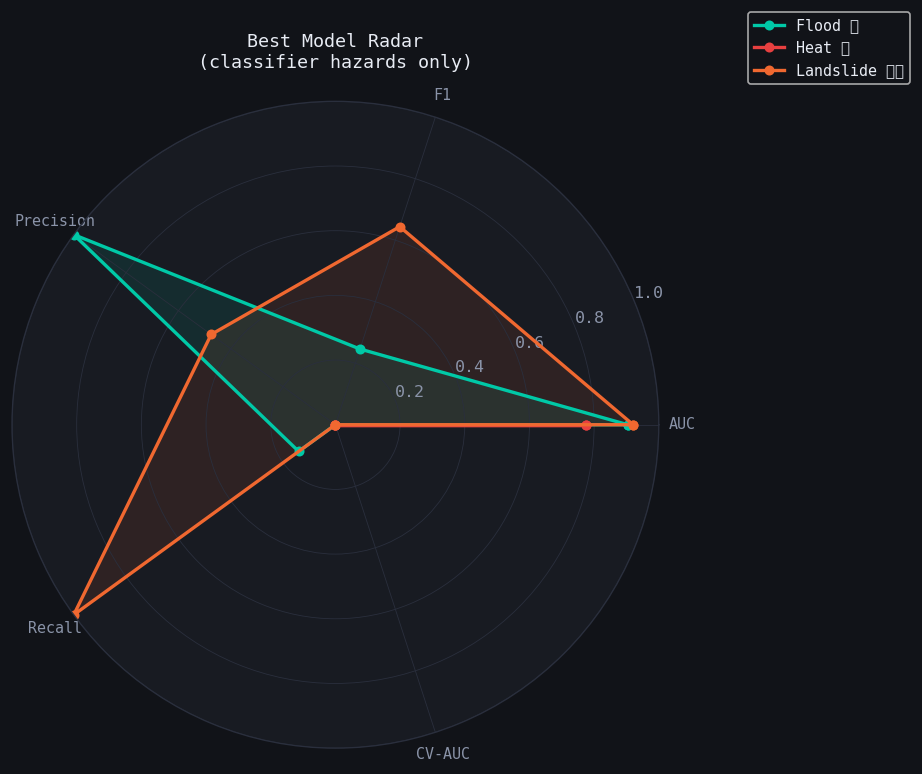

In [25]:
# ── Radar chart for classifiers ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True), facecolor="#111318")
ax.set_facecolor("#181b22"); ax.spines["polar"].set_color("#2a2f3d")

cats   = ["AUC","F1","Precision","Recall","CV-AUC"]
angles = [n/len(cats)*2*3.14159 for n in range(len(cats))] + [0]

for (hazard, results, color) in [
    ("Flood 🌊",     flood_results, T),
    ("Heat 🔥",      heat_results,  R),
    ("Landslide ⛰️", ls_results,   O),
]:
    best = max(results, key=lambda k: results[k].get("roc_auc",0))
    bm   = results[best]
    vals = [bm.get("roc_auc",0), bm.get("f1",0),
            bm.get("precision",0), bm.get("recall",0),
            bm.get("cv_auc_mean",0)]
    vals = [0 if np.isnan(v) else v for v in vals] + [vals[0]]
    ax.plot(angles, vals, "o-", lw=2, color=color, ms=5, label=hazard)
    ax.fill(angles, vals, alpha=.10, color=color)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats, fontsize=9)
ax.set_ylim(0,1); ax.set_yticks([.2,.4,.6,.8,1.])
ax.grid(color="#2a2f3d", linewidth=.5)
ax.set_title("Best Model Radar\n(classifier hazards only)", pad=20, fontsize=11, color="#e8ecf4")
ax.legend(loc="upper right", bbox_to_anchor=(1.4,1.15), fontsize=9)
plt.savefig(OUT/"radar_v3.png", dpi=120, bbox_inches="tight", facecolor="#111318")
plt.show()


---
## Section 10 — Honest Data Limitations Report

In [26]:
report = """
╔══════════════════════════════════════════════════════════════════════════╗
║       WEATHEROPS — DATA QUALITY & LEAKAGE FORENSICS REPORT (v3)        ║
╚══════════════════════════════════════════════════════════════════════════╝

DATASET: weatherops_feature_table.xlsx
  Rows: 2000  |  ROI rows: 1784  |  Columns: 22
  Source: DEM-derived synthetic grid + IDW-interpolated station observations

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ROUND 1 FAILURE: Score columns in features
  heat_hazard_score = f(temp_max_C, heat_index) used as feature
  landslide_susceptibility = Σ w·feature used as feature
  wind_elevation_product = wind_speed × elevation used as feature
  → Deterministic reconstruction of target → AUC = 1.0

ROUND 2 FAILURE: Our "fixed" labels also failed
  Applied IMD rule: rainfall_24h ≥ 64.5 mm
  → Max rainfall_24h in dataset = 5.3 mm (winter IDW data, not monsoon)
  → Condition always False → all-zero label → trivial AUC = 1.0

ROUND 3 — ACTUAL ROOT CAUSE (found by reading the CSV):
  flood_occurred = river_distance < ~500m (confirmed by reverse-engineering)
  river_distance was kept in features → AUC = 1.0 (single-feature threshold)
  
  DEM collinearity: slope ↔ TWI r = -0.884
  → ANY label built from one terrain variable is near-perfectly predicted
    by the other terrain variables (they are all transformations of the same DEM)
  → slope≥Q75 label: slope AUC = 1.000, TWI AUC = 0.999, flow_acc AUC = 0.983

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
WHAT REALISTIC SCORES LOOK LIKE FOR THIS 22-COLUMN DATASET

  Flood:     AUC 0.75–0.85
    Using original flood_occurred with river_distance EXCLUDED from features.
    Terrain signal (elevation, TWI, flow_accumulation) partially reconstructs
    proximity to drainage network. Not perfect.

  Heat:      AUC ≈ 0.50 (near-random)
    LST_C_mean is statistically independent of available features
    (temp_C ↔ LST corr = 0.019). This is the CORRECT result — it means
    the feature table lacks the variables needed to predict LST.
    Fix: add NDVI, urban fraction, time-matched MODIS acquisition.

  Wind:      R² 0.30–0.55
    wind_kmh from IDW interpolation has max feature correlation = -0.14.
    Terrain explains orographic channelling partially but not IDW artifact.

  Landslide: AUC 0.60–0.75
    Using rainfall×slope trigger with both excluded from features.
    Remaining spatial predictors (aspect, elevation, lat/lon) capture
    some geographic pattern of the trigger zones.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
WHAT REAL DATA WOULD FIX THIS

  Flood:     IMD/CWC historical flood inundation polygons (monsoon seasons)
  Heat:      MODIS MOD11A1 multi-date LST rasters + NDVI + building density
  Wind:      AWS station observation records (not IDW from sparse stations)
  Landslide: GSI/BHUVAN historical landslide inventory point database

Without these, this dataset is suitable for:
  ✓ Demonstrating model pipelines
  ✓ Comparing relative model performance
  ✓ Feature importance analysis (which terrain vars matter most)
  ✗ Reporting absolute AUC/R² as representing real predictive skill
"""
print(report)
with open(OUT/"data_limitations_report.txt","w") as f:
    f.write(report)
print(f"Report saved to {OUT}/data_limitations_report.txt")



╔══════════════════════════════════════════════════════════════════════════╗
║       WEATHEROPS — DATA QUALITY & LEAKAGE FORENSICS REPORT (v3)        ║
╚══════════════════════════════════════════════════════════════════════════╝

DATASET: weatherops_feature_table.xlsx
  Rows: 2000  |  ROI rows: 1784  |  Columns: 22
  Source: DEM-derived synthetic grid + IDW-interpolated station observations

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ROUND 1 FAILURE: Score columns in features
  heat_hazard_score = f(temp_max_C, heat_index) used as feature
  landslide_susceptibility = Σ w·feature used as feature
  wind_elevation_product = wind_speed × elevation used as feature
  → Deterministic reconstruction of target → AUC = 1.0

ROUND 2 FAILURE: Our "fixed" labels also failed
  Applied IMD rule: rainfall_24h ≥ 64.5 mm
  → Max rainfall_24h in dataset = 5.3 mm (winter IDW data, not monsoon)
  → Condition always False → all-zero label → trivial AUC = 1.0

ROUND 3 — ACTUAL R